In [1]:
suppressPackageStartupMessages({
  library(future)
  library(Seurat)
  library(tidyverse)
  library(Seurat)
  library(ggplot2)
  library(ggrastr)   # for geom_point_rast()
  library(ggrepel)   # for geom_text_repel()
  library(dplyr)
  library(forcats)
  library(pals)      # for glasbey palette (distinct, color-blind-friendly)
  library(stringr)  
  library(RColorBrewer) # For generating high-quality color palettes
  library(cowplot)      # For the 'theme_cowplot' (a clean, minimal theme)
  library(clusterProfiler)
  library(org.Hs.eg.db)
  library(enrichplot)
})

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Warning message:
“package ‘sp’ was built under R version 4.4.3”


Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
Warning message:
“package ‘ggrastr’ was built under R version 4.4.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.4.3”
Warning message:
“package ‘pals’ was built under R version 4.4.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.4.3”
Warning message:
“package ‘cowplot’ was built under R version 4.4.3”


In [2]:
# myeloid <- readRDS('/mnt/18T/chibao/gliomas/data_official/02_myeloid/01_myeloid_integrated_harmony_obj.rds')
myeloid <- readRDS('/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/harmony/obj/01_myeloid_integrated_cohort_new_harmony_obj.rds')
myeloid
myeloid@meta.data |> head()

An object of class Seurat 
72233 features across 184435 samples within 2 assays 
Active assay: SCT (33627 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AACAACCGTGTATTGC-1,PRJNA1125010,19800,4982,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,0.5252525,singlet,⋯,7,7,10,6,6,6,6,4,4,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AACCATGCATATACCG-1,PRJNA1125010,1175,713,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,10.9787234,singlet,⋯,3,4,2,1,1,1,0,0,0,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AACCCAAAGGAGTATT-1,PRJNA1125010,52267,7661,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,3.6083954,singlet,⋯,7,7,10,6,49,6,57,4,4,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AATCACGGTAGGCAAC-1,PRJNA1125010,7263,2544,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,4.9979347,singlet,⋯,7,7,10,6,49,6,57,4,4,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AATTCCTGTGAGATAT-1,PRJNA1125010,12366,4766,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,5.4585153,singlet,⋯,8,10,7,8,8,7,12,7,7,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AATTTCCCAGTATTCG-1,PRJNA1125010,4284,2090,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,1.9607843,singlet,⋯,9,8,8,15,23,23,24,27,27,Myeloid


In [3]:
myeloid@meta.data$orig.ident |> unique()

[1] "PRJNA1125010" "PRJNA1131103" "PRJNA1134206" "PRJNA1141154" "PRJNA1212512"
 [6] "PRJNA647809"  "PRJNA683876"  "PRJNA887804"  "PRJNA887805"  "PRJNA995768"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



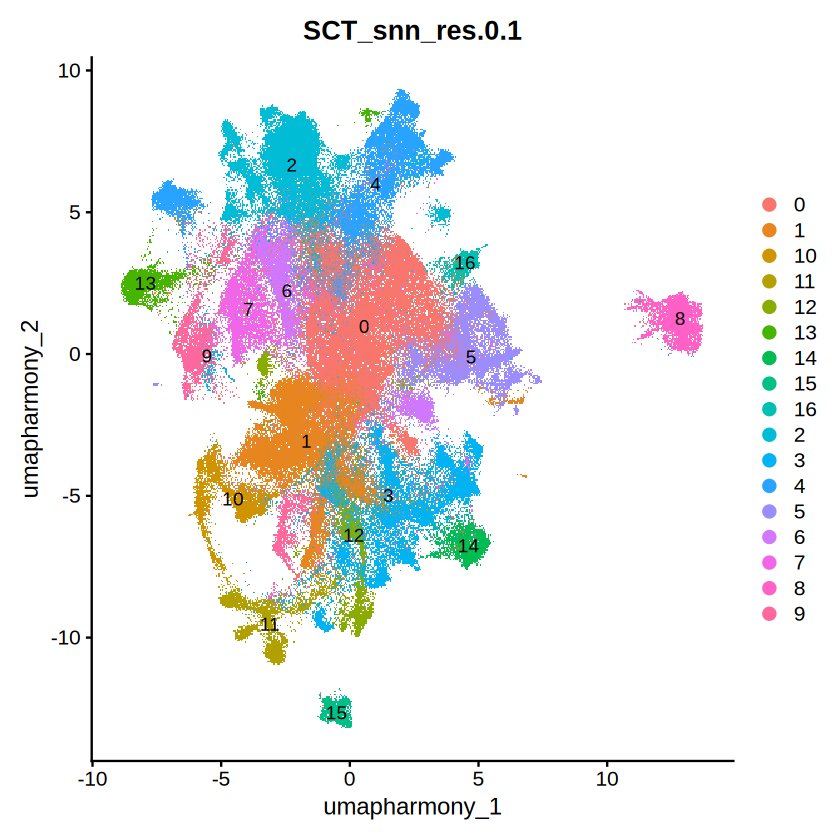

In [4]:
DimPlot(myeloid, reduction = 'umap.harmony', group.by = 'SCT_snn_res.0.1', label = TRUE)

In [5]:
myeloid <- PrepSCTFindMarkers(myeloid, assay = 'SCT', verbose = TRUE)

Found 10 SCT models. Recorrecting SCT counts using minimum median counts: 1321



In [ ]:
# harmony_obj <- PrepSCTFindMarkers(harmony_obj, assay = 'SCT', verbose = TRUE)
# # Res 0.1
# Idents(harmony_obj) <- 'SCT_snn_res.0.1'
# harmony_obj_markers_0.1 <- FindAllMarkers(harmony_obj, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

# # Res 0.2 
# Idents(harmony_obj) <- 'SCT_snn_res.0.2'
# harmony_obj_markers_0.2 <- FindAllMarkers(harmony_obj, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

# harmony <- PrepSCTFindMarkers(harmony, assay = 'SCT', verbose = TRUE)
# # Res 0.1
# Idents(harmony) <- 'SCT_snn_res.0.1'
# harmony_markers_0.1 <- FindAllMarkers(harmony, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

# # Res 0.2 
# Idents(harmony) <- 'SCT_snn_res.0.2'
# harmony_markers_0.2 <- FindAllMarkers(harmony, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

# harmony_obj_markers_0.1 <- harmony_obj_markers_0.1 |> arrange(desc(avg_log2FC))
# harmony_obj_markers_0.2 <- harmony_obj_markers_0.2 |> arrange(desc(avg_log2FC))

# harmony_markers_0.1 <- harmony_markers_0.1 |> arrange(desc(avg_log2FC))
# harmony_markers_0.2 <- harmony_markers_0.2 |> arrange(desc(avg_log2FC))

write.csv(harmony_obj_markers_0.1, file = '/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/harmony/markers/harmony_obj_markers_new_0.1.csv')
write.csv(harmony_obj_markers_0.2, file = '/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/harmony/markers/harmony_obj_markers_new_0.2.csv')
write.csv(harmony_markers_0.1, file = '/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/harmony/markers/harmony_markers_new_0.1.csv')
write.csv(harmony_markers_0.2, file = '/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/harmony/markers/harmony_markers_new_0.2.csv')


In [5]:
Idents(myeloid) <- 'SCT_snn_res.0.08'

In [6]:
all_markers <- FindAllMarkers(myeloid, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

Calculating cluster 0



Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11



In [7]:
cluster0 <- all_markers %>% filter(cluster == 0) %>% arrange(desc(avg_log2FC))
cluster1 <- all_markers %>% filter(cluster == 1) %>% arrange(desc(avg_log2FC))
cluster2 <- all_markers %>% filter(cluster == 2) %>% arrange(desc(avg_log2FC))
cluster3 <- all_markers %>% filter(cluster == 3) %>% arrange(desc(avg_log2FC))
cluster4 <- all_markers %>% filter(cluster == 4) %>% arrange(desc(avg_log2FC))
cluster5 <- all_markers %>% filter(cluster == 5) %>% arrange(desc(avg_log2FC))
cluster6 <- all_markers %>% filter(cluster == 6) %>% arrange(desc(avg_log2FC))
cluster7 <- all_markers %>% filter(cluster == 7) %>% arrange(desc(avg_log2FC))
cluster8 <- all_markers %>% filter(cluster == 8) %>% arrange(desc(avg_log2FC))
cluster9 <- all_markers %>% filter(cluster == 9) %>% arrange(desc(avg_log2FC))
cluster10 <- all_markers %>% filter(cluster == 10) %>% arrange(desc(avg_log2FC))
cluster11 <- all_markers %>% filter(cluster == 11) %>% arrange(desc(avg_log2FC))

In [8]:
cluster8 |> head(10)
cluster9 |> head(10)
cluster10 |> head(10)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
UBE2C,0,6.092567,0.557,0.012,0,8,UBE2C
MKI67,0,5.773833,0.565,0.013,0,8,MKI67
GTSE1,0,5.682368,0.295,0.006,0,8,GTSE1
ASPM,0,5.681640,0.334,0.008,0,8,ASPM
TOP2A,0,5.676366,0.570,0.015,0,8,TOP2A
TPX2,0,5.405128,0.393,0.011,0,8,TPX2
RRM2,0,5.328570,0.384,0.012,0,8,RRM2
NUSAP1,0,5.304240,0.547,0.017,0,8,NUSAP1
CCNB1,0,5.271578,0.266,0.009,0,8,CCNB1


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
LINC03051,0,5.882230,0.260,0.006,0,9,LINC03051
LRRTM4,0,5.618332,0.352,0.012,0,9,LRRTM4
NCAM2,0,5.504278,0.317,0.012,0,9,NCAM2
CADPS,0,5.487056,0.256,0.008,0,9,CADPS
CTNND2,0,5.380775,0.365,0.014,0,9,CTNND2
CTNNA2,0,5.347593,0.323,0.011,0,9,CTNNA2
NRXN1,0,5.324133,0.430,0.020,0,9,NRXN1
SOX6,0,5.198925,0.420,0.019,0,9,SOX6
GRIA2,0,5.150439,0.296,0.011,0,9,GRIA2


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
CD79B,0,5.458555,0.263,0.006,0,10,CD79B
SNED1,0,5.193607,0.261,0.009,0,10,SNED1
CDKN1C,0,5.136069,0.584,0.028,0,10,CDKN1C
HERC2P3,0,4.464377,0.254,0.016,0,10,HERC2P3
SPN,0,4.156207,0.363,0.022,0,10,SPN
LTB,0,3.857481,0.256,0.017,0,10,LTB
ITGAL,0,3.785669,0.432,0.036,0,10,ITGAL
PELATON,0,3.761248,0.589,0.059,0,10,PELATON
LRRC25,0,3.587790,0.532,0.050,0,10,LRRC25


In [28]:
# write out the cluster11 dataframe to CSV
write.csv(cluster11, file = "cluster11.csv", row.names = FALSE)

In [26]:
microglia <- cluster11 |> filter(gene %in% c('TMEM119', 'P2RY12', 'TREM2'))
microglia

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
TREM22,3.057501e-132,1.600454,0.466,0.213,9.556829e-128,11,TREM2
P2RY12,2.857405e-113,1.433914,0.314,0.113,8.931392e-109,11,P2RY12


# Dot Plot

In [18]:
Idents(myeloid) <- 'SCT_snn_res.0.08'

In [ ]:
# Range
# top_markers <- cluster1$gene[1:15]
top_markers <- c('CD74', 'CD14', 'LYZ', 'VCAN', 'ITGAM')
# Flatten the markers for DotPlot
markers_genes <- unlist(top_markers)
markers_genes <- make.unique(markers_genes)

# Set factor levels in the order of your original markers vector
markers_genes <- factor(markers_genes, levels = markers_genes)

# Create a mapping from gene -> "Cluster0:Gene" label
label_map <- setNames(
  paste0("ClusterX:", markers_genes),
  markers_genes
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


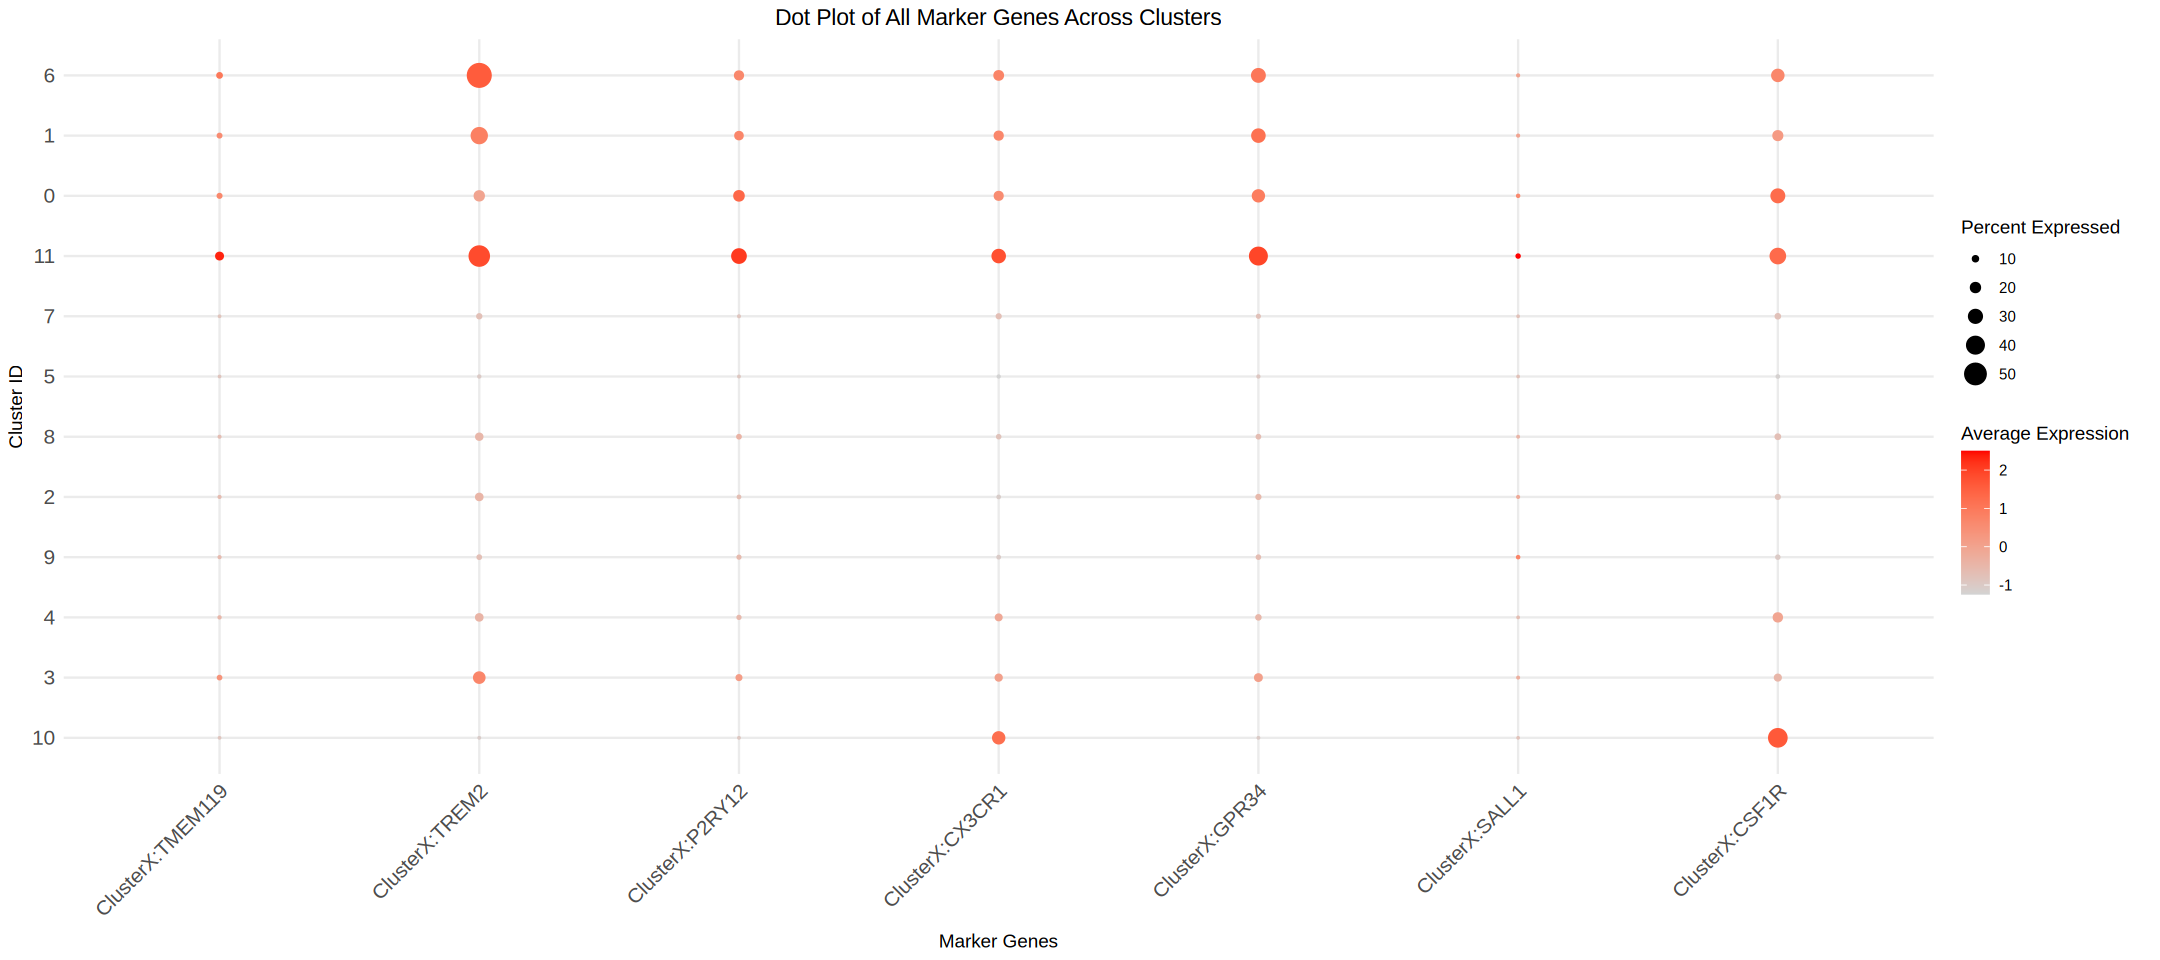

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 8)

p <- DotPlot(harmony, features = markers_genes, cluster.idents = TRUE) +
  scale_color_gradient(low = "lightgrey", high = "red") +
  theme_minimal() +
  xlab("Marker Genes") +
  ylab("Cluster ID") +
  ggtitle("Dot Plot of All Marker Genes Across Clusters") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    plot.title  = element_text(hjust = 0.5)
  ) +
  # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
  scale_x_discrete(labels = label_map)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



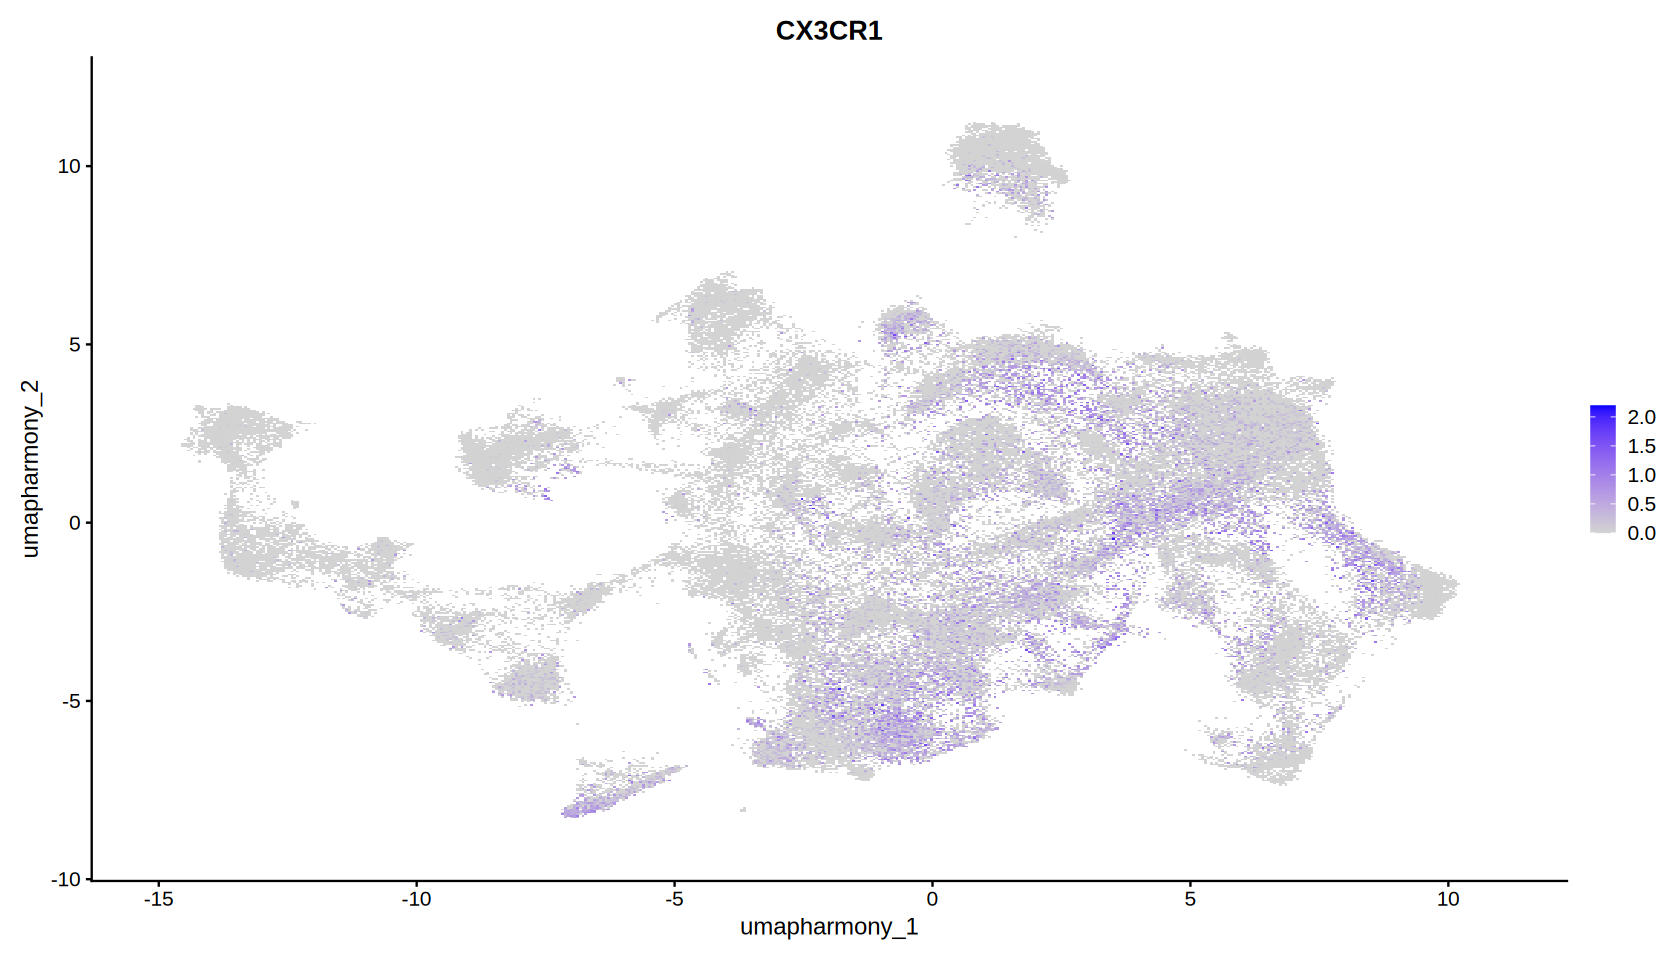

In [34]:
options(repr.plot.width = 14, repr.plot.height = 8)
FeaturePlot(myeloid, features = c("CX3CR1"), reduction = 'umap.harmony', ncol = 1)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



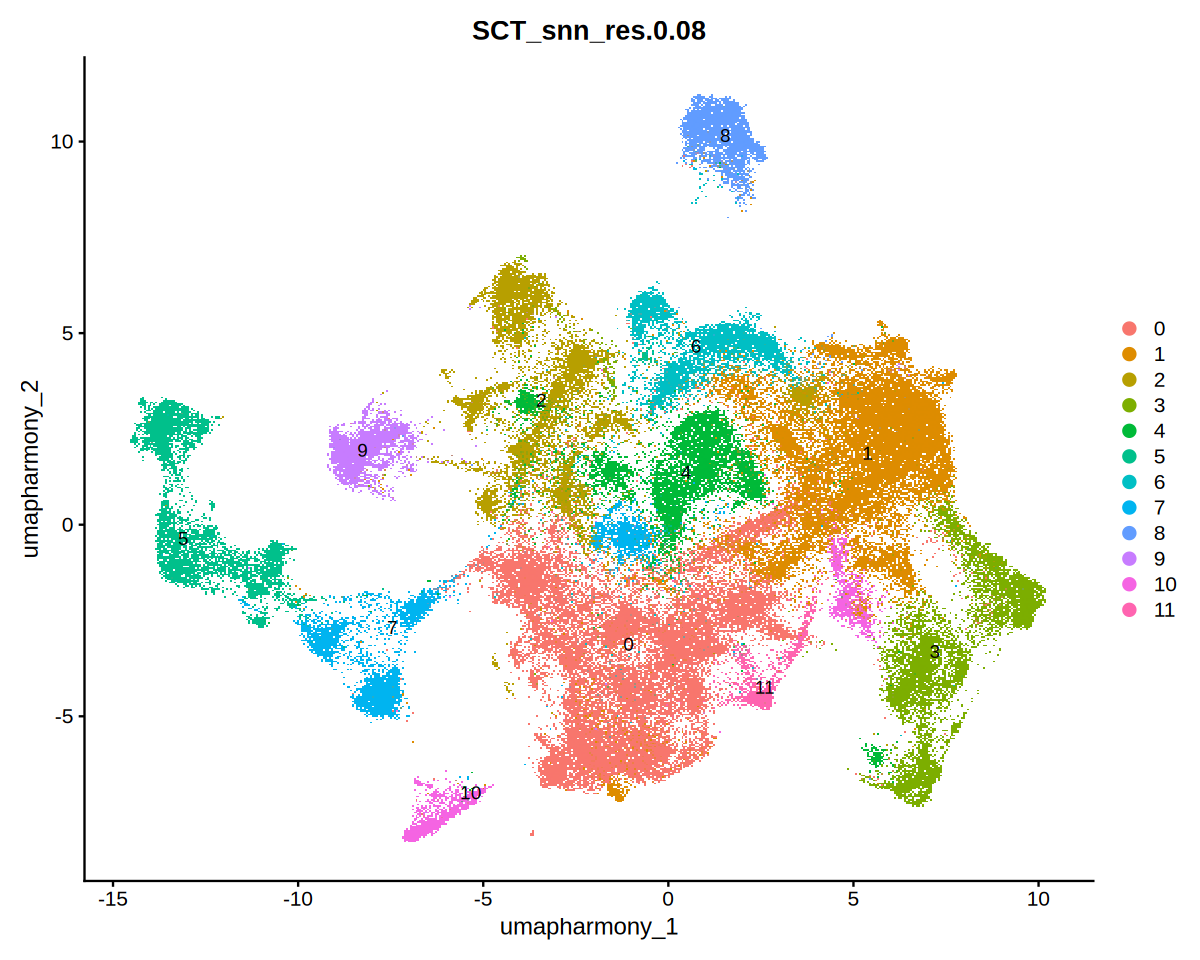

In [35]:
options(repr.plot.width = 10, repr.plot.height = 8)
DimPlot(myeloid, reduction = 'umap.harmony', group.by = 'SCT_snn_res.0.08', label = TRUE)